In [27]:
import torch
import os

train_dir = "3ed_trai_h_graphs_hetero_graphs"
# Safely grab the first .pt file
files = [f for f in os.listdir(train_dir) if f.endswith('.pt')]
first_file = files[0]
data = torch.load(os.path.join(train_dir, first_file))

print("=== GRAPH SUMMARY ===")
print(data)

print("\n=== EDGE ATTRIBUTES ===")
for edge_type in data.edge_types:
    print(f"Edge: {edge_type}")
    for key in data[edge_type].keys():
        val = data[edge_type][key]
        if isinstance(val, torch.Tensor):
            print(f"  - {key}: Tensor of shape {val.shape}")
        else:
            print(f"  - {key}: {type(val)}")

print("\n=== NODE ATTRIBUTES ===")
for node_type in data.node_types:
    print(f"Node: {node_type}")
    for key in data[node_type].keys():
        val = data[node_type][key]
        if isinstance(val, torch.Tensor):
            print(f"  - {key}: Tensor of shape {val.shape}")
        else:
            print(f"  - {key}: {type(val)}")

print("\n=== GLOBAL ATTRIBUTES ===")
for key in data.keys():
    if key not in data.node_types and key not in data.edge_types:
        val = data[key]
        if isinstance(val, torch.Tensor):
            print(f"  - {key}: Tensor of shape {val.shape}")
        else:
            print(f"  - {key}: {type(val)}")

=== GRAPH SUMMARY ===
HeteroData(
  ip={
    num_nodes=216,
    community=[216],
    x=[216, 1],
  },
  (ip, network, ip)={
    edge_index=[2, 199],
    edge_attr=[199, 4],
    edge_label=[199],
  }
)

=== EDGE ATTRIBUTES ===
Edge: ('ip', 'network', 'ip')
  - edge_index: Tensor of shape torch.Size([2, 199])
  - edge_attr: Tensor of shape torch.Size([199, 4])
  - edge_label: Tensor of shape torch.Size([199])

=== NODE ATTRIBUTES ===
Node: ip
  - num_nodes: <class 'int'>
  - community: Tensor of shape torch.Size([216])
  - x: Tensor of shape torch.Size([216, 1])

=== GLOBAL ATTRIBUTES ===
  - edge_attr: <class 'torch_geometric.data.storage.NodeStorage'>
  - edge_index: <class 'torch_geometric.data.storage.NodeStorage'>
  - x: <class 'torch_geometric.data.storage.NodeStorage'>
  - num_nodes: <class 'torch_geometric.data.storage.NodeStorage'>
  - edge_label: <class 'torch_geometric.data.storage.NodeStorage'>
  - community: <class 'torch_geometric.data.storage.NodeStorage'>


Using device: cpu
Loaded 251 training graphs.
[DEBUG] Out of 251 training graphs, only 251 had labels.
[DEBUG] Training Class Distribution -> Benign (0): 277669, Attack (1): 363
[Epoch 1/50] Loss: 0.0239
[Epoch 2/50] Loss: 0.0138
[Epoch 3/50] Loss: 0.0131
[Epoch 4/50] Loss: 0.0129
[Epoch 5/50] Loss: 0.0126
[Epoch 6/50] Loss: 0.0128
[Epoch 7/50] Loss: 0.0125
[Epoch 8/50] Loss: 0.0124
[Epoch 9/50] Loss: 0.0120
[Epoch 10/50] Loss: 0.0119
[Epoch 11/50] Loss: 0.0119
[Epoch 12/50] Loss: 0.0121
[Epoch 13/50] Loss: 0.0121
[Epoch 14/50] Loss: 0.0121
[Epoch 15/50] Loss: 0.0122
[Epoch 16/50] Loss: 0.0122
[Epoch 17/50] Loss: 0.0123
[Epoch 18/50] Loss: 0.0124
[Epoch 19/50] Loss: 0.0125
[Epoch 20/50] Loss: 0.0123
[Epoch 21/50] Loss: 0.0121
[Epoch 22/50] Loss: 0.0120
[Epoch 23/50] Loss: 0.0121
[Epoch 24/50] Loss: 0.0123
[Epoch 25/50] Loss: 0.0121
[Epoch 26/50] Loss: 0.0121
[Epoch 27/50] Loss: 0.0125
[Epoch 28/50] Loss: 0.0123
[Epoch 29/50] Loss: 0.0124
[Epoch 30/50] Loss: 0.0121
[Epoch 31/50] Loss: 0

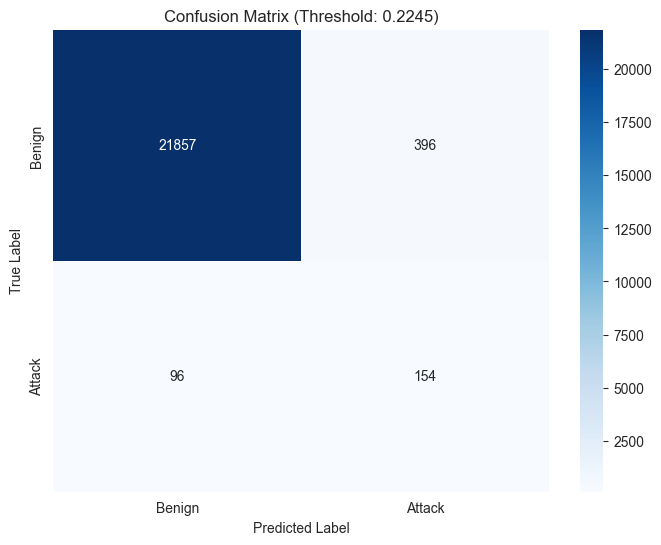

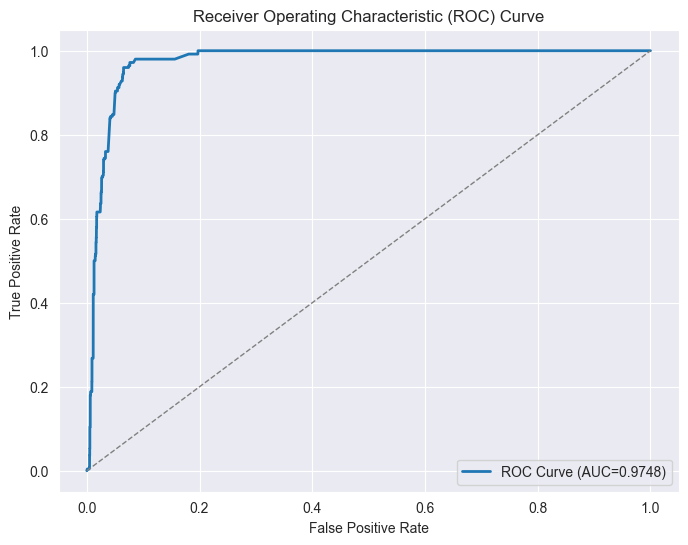

In [29]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, GCNConv
from sklearn.metrics import (
    roc_auc_score, 
    precision_recall_fscore_support, 
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#######################
# 1) HeteroEdgeClassifier Model
#######################
class HeteroEdgeClassifier(nn.Module):
    def __init__(self, active_edges, hidden_channels=64, out_channels=32, num_classes=2):
        super().__init__()

        # Dynamically build convolutions based on the active_edges configuration
        conv1_dict = {}
        conv2_dict = {}
        
        for edge_name in active_edges:
            # Assumes your edges connect 'ip' to 'ip'
            rel = ('ip', edge_name, 'ip') 
            
            # Use -1 for Lazy Initialization of input features
            conv1_dict[rel] = GCNConv(-1, hidden_channels)
            conv2_dict[rel] = GCNConv(hidden_channels, hidden_channels)

        self.conv1 = HeteroConv(conv1_dict, aggr='sum')
        self.bn1_ip = nn.BatchNorm1d(hidden_channels)

        self.conv2 = HeteroConv(conv2_dict, aggr='sum')
        self.bn2_ip = nn.BatchNorm1d(hidden_channels)

        self.lin_node = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels * 2),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_channels * 2, out_channels),
            nn.ReLU()
        )

        self.lin_edge = nn.Sequential(
            nn.Linear(out_channels * 2, out_channels),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(out_channels, out_channels),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(out_channels, num_classes)
        )

    def forward(self, data):
        x_dict = self.conv1(data.x_dict, data.edge_index_dict)
        
        # Safety Check: If a graph is completely missing all active edge types,
        # HeteroConv will drop the 'ip' key. We inject a zero-tensor fallback.
        if 'ip' not in x_dict:
            num_nodes = data.x_dict['ip'].size(0)
            device = data.x_dict['ip'].device
            x_dict['ip'] = torch.zeros((num_nodes, self.bn1_ip.num_features), device=device)
            
        x_dict['ip'] = self.bn1_ip(x_dict['ip'])
        x_dict['ip'] = F.relu(x_dict['ip'])

        x_dict = self.conv2(x_dict, data.edge_index_dict)
        
        if 'ip' not in x_dict:
            num_nodes = data.x_dict['ip'].size(0)
            device = data.x_dict['ip'].device
            x_dict['ip'] = torch.zeros((num_nodes, self.bn2_ip.num_features), device=device)

        x_dict['ip'] = self.bn2_ip(x_dict['ip'])
        x_dict['ip'] = F.relu(x_dict['ip'])

        x_dict['ip'] = self.lin_node(x_dict['ip'])
        return x_dict

    def edge_classify(self, z_src, z_dst):
        z_cat = torch.cat([z_src, z_dst], dim=-1)
        logits = self.lin_edge(z_cat)
        return logits

##############################
# 2) Focal Loss
##############################
def focal_loss(logits, targets, alpha=0.25, gamma=2.0):
    ce_loss = F.cross_entropy(logits, targets, reduction='none')
    pt = torch.exp(-ce_loss)
    return (alpha * (1 - pt)**gamma * ce_loss).mean()

##############################
# 3) Train Edge Classifier
##############################
def train_edge_classifier(model, graphs, epochs=10, device='cuda', alpha=0.25, gamma=2.0):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        graphs_with_labels = 0
        
        # Track class distribution for debugging
        total_class_0 = 0
        total_class_1 = 0

        for i, data in enumerate(graphs):
            data = data.to(device)
            optimizer.zero_grad()

            x_dict = model(data)
            z_ip = x_dict['ip']

            loss_graph = 0.0
            found_labels = False

            for rel_type in data.edge_types:
                if 'edge_label' not in data[rel_type]:
                    continue
                
                labels = data[rel_type].edge_label
                if labels.numel() == 0:
                    continue
                
                found_labels = True
                
                # Count classes
                total_class_0 += (labels == 0).sum().item()
                total_class_1 += (labels == 1).sum().item()

                edge_index = data[rel_type].edge_index
                src, dst = edge_index
                
                # Predict and calculate loss
                logits = model.edge_classify(z_ip[src], z_ip[dst])
                loss_rel = focal_loss(logits, labels, alpha=alpha, gamma=gamma)
                loss_graph += loss_rel

            if isinstance(loss_graph, torch.Tensor):
                graphs_with_labels += 1
                loss_graph.backward()
                optimizer.step()
                total_loss += loss_graph.item()

        # Print debug info on epoch 1
        if epoch == 1:
            print(f"[DEBUG] Out of {len(graphs)} training graphs, only {graphs_with_labels} had labels.")
            print(f"[DEBUG] Training Class Distribution -> Benign (0): {total_class_0}, Attack (1): {total_class_1}")

        avg_loss = total_loss / graphs_with_labels if graphs_with_labels > 0 else 0.0
        print(f"[Epoch {epoch}/{epochs}] Loss: {avg_loss:.4f}")

################################
# 4) Evaluate Edge Classifier
################################
@torch.no_grad()
def evaluate_edge_classifier(model, test_graphs, device='cuda'):
    model.eval()
    model.to(device)

    all_scores = []
    all_labels = []
    graphs_with_labels = 0

    for data in test_graphs:
        data = data.to(device)
        x_dict = model(data)
        z_ip = x_dict['ip']
        
        found_labels = False

        for rel_type in data.edge_types:
            if 'edge_label' not in data[rel_type]:
                continue
            labels = data[rel_type].edge_label
            if labels.numel() == 0:
                continue

            found_labels = True
            edge_index = data[rel_type].edge_index
            src, dst = edge_index
            
            logits = model.edge_classify(z_ip[src], z_ip[dst])
            probs = F.softmax(logits, dim=-1)[:, 1]
            
            all_scores.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            
        if found_labels:
            graphs_with_labels += 1

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)
    
    print(f"\n[Test Evaluation]")
    print(f"Processed {graphs_with_labels}/{len(test_graphs)} test graphs that contained labels.")
    
    if len(all_labels) == 0:
        print("ERROR: Absolutely no labels were found in the test set. Cannot evaluate.")
        return

    unique_classes, counts = np.unique(all_labels, return_counts=True)
    print(f"Test Set Class Distribution: {dict(zip(unique_classes, counts))}")

    if len(unique_classes) < 2:
        print("WARNING: Only one class present in the test set. AUC and ROC curve cannot be calculated.")
        return

    # --- DYNAMIC THRESHOLD CALCULATION ---
    auc = roc_auc_score(all_labels, all_scores)
    
    # Generate precision and recall arrays for every possible threshold
    precision_curve, recall_curve, thresholds = precision_recall_curve(all_labels, all_scores)
    
    # Drop the last element of precision/recall to match thresholds array length
    p = precision_curve[:-1]
    r = recall_curve[:-1]
    
    # Calculate the F1 Score for every threshold
    f1_scores = 2 * (p * r) / (p + r + 1e-8)
    
    # Find the threshold that produced that highest F1 Score
    optimal_idx = np.argmax(f1_scores)
    best_threshold = thresholds[optimal_idx]
    
    print(f"\nModel AUC: {auc:.4f}")
    print(f"Calculated Optimal Threshold: {best_threshold:.6f}")
    # -------------------------------------

    # Apply the newly calculated threshold
    final_preds = (all_scores >= best_threshold).astype(int)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, final_preds, average='binary', zero_division=0
    )
    accuracy = accuracy_score(all_labels, final_preds)
    cm = confusion_matrix(all_labels, final_preds)

    print(f"Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, Accuracy={accuracy:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold: {best_threshold:.4f})")
    plt.savefig("confusion_matrix.png")
    plt.show()

    fpr, tpr, _ = roc_curve(all_labels, all_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC={auc:.4f})", lw=2)
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.savefig("roc_curve.png")
    plt.show()

###############################
# 5) Data-Loading Helpers
###############################
def load_single_graph(directory, filename):
    path = os.path.join(directory, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found.")

    data = torch.load(path, weights_only=False)

    for rel_type in data.edge_types:
        if 'edge_label' in data[rel_type]:
            lbl = data[rel_type].edge_label
            
            # 1. Convert to tensor if it is currently a list or numpy array
            if not isinstance(lbl, torch.Tensor):
                lbl = torch.tensor(lbl, dtype=torch.long)
                
            # 2. Apply mapping
            lbl = torch.where(lbl < 0, torch.tensor(0, device=lbl.device), lbl)
            lbl = torch.where(lbl > 1, torch.tensor(1, device=lbl.device), lbl)
            
            data[rel_type].edge_label = lbl

    return data

#########################
# 6) Main Script
#########################
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    
    # --- CONFIGURATION BLOCK ---
    identifiers = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'Attack']
    network_features = ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration']
    context_features = ['Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Fwd Act Data Pkts', 'Down/Up Ratio', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']
    knowledge_features = ['Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Seg Size Min', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var']

    CONFIG = 'B'  # Change to 'A', 'B', 'C', or 'D'

    if CONFIG == 'A':
        features_to_keep = identifiers + network_features
        active_edges = {'network'}
    elif CONFIG == 'B':
        features_to_keep = identifiers + network_features + context_features
        active_edges = {'network', 'context'}
    elif CONFIG == 'C':
        features_to_keep = identifiers + network_features + knowledge_features
        active_edges = {'network', 'knowledge'}
    elif CONFIG == 'D':
        features_to_keep = identifiers + network_features + context_features + knowledge_features
        active_edges = {'network', 'context', 'knowledge'}
    # ---------------------------

    train_dir = "3ed_trai_h_graphs_hetero_graphs"
    train_files = [f for f in os.listdir(train_dir) if f.endswith('.pt')]
    train_graphs = [load_single_graph(train_dir, f) for f in train_files]

    print(f"Loaded {len(train_graphs)} training graphs.")

    hidden_channels = 64
    out_channels = 32
    
    # Initialize the model dynamically passing the 'active_edges' set
    model = HeteroEdgeClassifier(active_edges, hidden_channels, out_channels)

    train_edge_classifier(model, train_graphs, epochs=50, device=device, alpha=0.9, gamma=2.0)

    test_dir = "3ed_tes_h_graphs_hetero_graphs"
    test_files = [f for f in os.listdir(test_dir) if f.endswith('.pt')]
    test_graphs = [load_single_graph(test_dir, f) for f in test_files]

    print(f"Loaded {len(test_graphs)} test graph(s).")

    # Evaluate using dynamic optimal thresholding
    evaluate_edge_classifier(model, test_graphs, device=device)